# Pneumonia classider 

In [7]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import itertools
import warnings
warnings.filterwarnings("ignore")

In [16]:
tf.random.set_seed(42)
SEED = 42

## Dataset path

In [3]:
DATA_DIR = 'dataset'
TRAIN_DIR =os.path.join(DATA_DIR,"train")
TEST_DIR =os.path.join(DATA_DIR,"test")
VAL_DIR =os.path.join(DATA_DIR,"val")

print("Train:",TRAIN_DIR)
print("val:",VAL_DIR)
print("Test:",TEST_DIR)

Train: dataset\train
val: dataset\val
Test: dataset\test


## Check Class Distribution

In [4]:
def count_images(folder):
    classes = sorted(os.listdir(folder))
    counts = {}
    for c in classes:
        p = os.path.join(folder, c)
        if os.path.isdir(p):
            counts[c] = len(os.listdir(p))
    return counts

In [5]:
print("Train distribution:", count_images(TRAIN_DIR))
print("Val distribution:", count_images(VAL_DIR))
print("Test distribution:", count_images(TEST_DIR))

Train distribution: {'NORMAL': 3400, 'PNEUMONIA': 3400}
Val distribution: {'NORMAL': 850, 'PNEUMONIA': 850}
Test distribution: {'NORMAL': 15, 'PNEUMONIA': 15}


## Visualize Random Images

In [9]:
def show_random_images(folder, n=8):
    classes = sorted([c for c in os.listdir(folder) if os.path.isdir(os.path.join(folder, c))])
    plt.figure(figsize=(14, 6))
    for i in range(n):
        cls = random.choice(classes)
        img_name = random.choice(os.listdir(os.path.join(folder, cls)))
        img_path = os.path.join(folder, cls, img_name)
        img = tf.keras.utils.load_img(img_path)
        plt.subplot(2, n//2, i+1)
        plt.imshow(img, cmap="gray")
        plt.title(cls)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

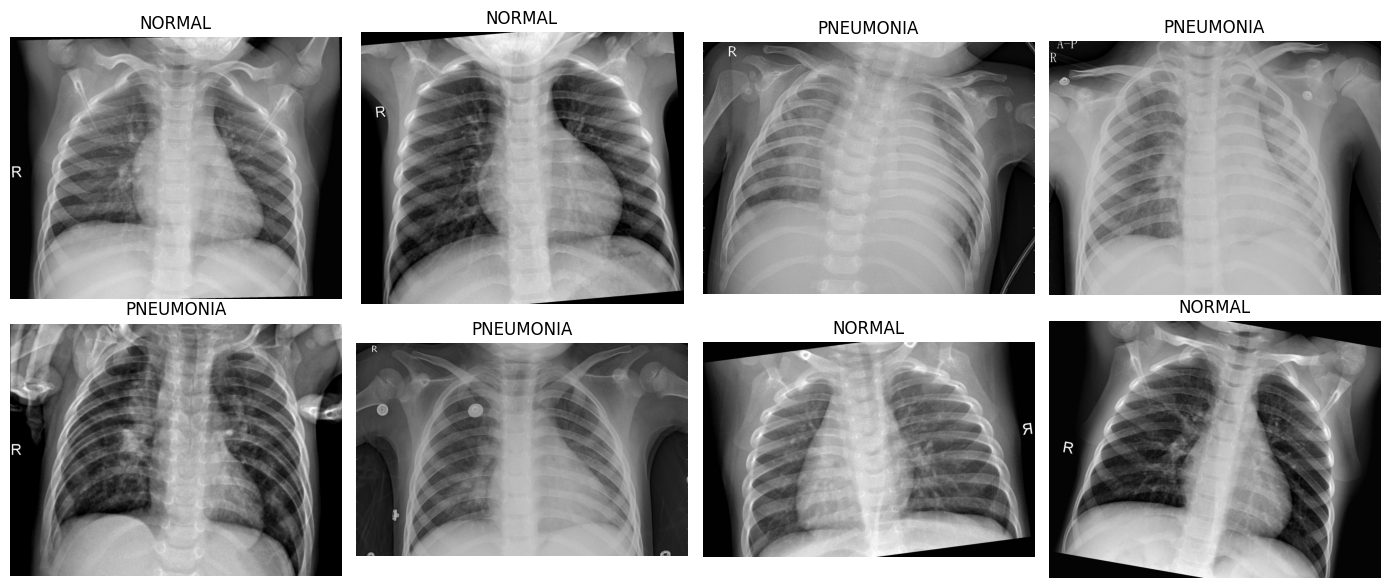

In [10]:
show_random_images(TRAIN_DIR, n=8)

## Check Image Size & Channels

In [12]:
sample_cls = sorted(os.listdir(TRAIN_DIR))[0]
sample_img = os.listdir(os.path.join(TRAIN_DIR, sample_cls))[0]
sample_path = os.path.join(TRAIN_DIR, sample_cls, sample_img)

img = tf.keras.utils.load_img(sample_path)
arr = tf.keras.utils.img_to_array(img)

print("Sample path:", sample_path)
print("Image shape:", arr.shape)

Sample path: dataset\train\NORMAL\IM-0001-0001.jpeg
Image shape: (1317, 1857, 3)


In [13]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

## Train Augmentation

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode="nearest"
)

## Validation/Test Generator

In [15]:
test_val_datagen = ImageDataGenerator(rescale=1./255)

##  Load Generators

In [17]:
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=True,
    seed=SEED
)

val_gen = test_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False
)

test_gen = test_val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False
)

print("Class indices:", train_gen.class_indices)  # e.g. {'NORMAL':0, 'PNEUMONIA':1}

Found 6800 images belonging to 2 classes.
Found 1700 images belonging to 2 classes.
Found 30 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


## Compute Class Weights

In [18]:
y_train = train_gen.classes
classes = np.unique(y_train)

weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {int(c): w for c, w in zip(classes, weights)}
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


## Creating model_1 (simple model)

In [21]:
model_1 = tf.keras.Sequential([
    

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')

])

model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model_1.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics= ['accuracy']
                )

In [27]:
history_model_1 = model_1.fit(train_gen,
                              validation_data=val_gen,
                              epochs= 10,
                              class_weight=class_weights,
                              verbose=1
                              )

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 189s 881ms/step - accuracy: 0.7021 - loss: 0.5511 - val_accuracy: 0.8588 - val_loss: 0.3608
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 123s 576ms/step - accuracy: 0.8674 - loss: 0.3248 - val_accuracy: 0.8512 - val_loss: 0.3182
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 124s 583ms/step - accuracy: 0.8837 - loss: 0.2738 - val_accuracy: 0.8800 - val_loss: 0.3108
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 124s 584ms/step - accuracy: 0.8947 - loss: 0.2485 - val_accuracy: 0.9188 - val_loss: 0.2149
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 125s 588ms/step - accuracy: 0.8956 - loss: 0.2535 - val_accuracy: 0.9076 - val_loss: 0.2407
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 125s 586ms/step - accuracy: 0.9076 - loss: 0.2287 - val_accuracy: 0.9212 - val_loss: 0.1962
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 133s 624ms/step - accuracy: 0.9106 - loss: 0.2149 - val_accuracy: 0.9294 - val_loss: 0.1931
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 131s 615ms/step - accuracy: 0.9087 -

In [33]:
import numpy as np

# probabilities (0 → 1)
y_pred_prob = model_1.predict(test_gen)

# convert to 0 or 1
y_pred = (y_pred_prob > 0.4).astype(int).flatten()

# true labels
y_true = test_gen.classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step


In [34]:

print(classification_report(y_true, y_pred, target_names=["Normal", "Pneumonia"]))

              precision    recall  f1-score   support

      Normal       1.00      0.87      0.93        15
   Pneumonia       0.88      1.00      0.94        15

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[13  2]
 [ 0 15]]


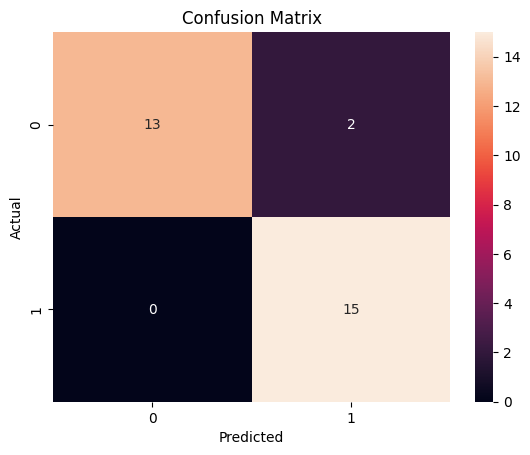

In [36]:
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9333333333333333


In [37]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, y_pred_prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.9866666666666667


### The model achieved 100% recall on pneumonia cases, ensuring no false negatives, with a slight trade-off in precision due to a few false positives. ROC-AUC of 0.98 indicates strong class separability

## model_2 

In [ ]:
model_2 = tf.keras.Sequential([
    
     tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    # 🔥 Extra depth
    layers.Conv2D(256, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    # Head
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 54, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 54, 54, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 27, 27, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 27, 27, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,977 (1.61 MB)

 Trainable params: 422,209 (1.61 MB)

 Non-trainable params: 768 (3.00 KB)

In [41]:
model_2.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics= ['accuracy']
                )

In [42]:
history_model_2 = model_2.fit(train_gen,
                              validation_data=val_gen,
                              epochs= 10,
                              class_weight=class_weights,
                              verbose=1
                              )

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 147s 681ms/step - accuracy: 0.8679 - loss: 0.3184 - val_accuracy: 0.5000 - val_loss: 1.4182
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 151s 710ms/step - accuracy: 0.9015 - loss: 0.2452 - val_accuracy: 0.8829 - val_loss: 0.2622
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 188s 883ms/step - accuracy: 0.9193 - loss: 0.2167 - val_accuracy: 0.5006 - val_loss: 2.4564
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 165s 773ms/step - accuracy: 0.9260 - loss: 0.1938 - val_accuracy: 0.7200 - val_loss: 1.4608
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.9325 - loss: 0.1776 - val_accuracy: 0.5000 - val_loss: 3.8188
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.9381 - loss: 0.1652 - val_accuracy: 0.7082 - val_loss: 0.9246
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 411s 2s/step - accuracy: 0.9418 - loss: 0.1584 - val_accuracy: 0.5429 - val_loss: 2.0409
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 468s 2s/step - accuracy: 0.9441 - loss: 0.148

In [43]:
import numpy as np

# probabilities (0 → 1)
y_pred_prob = model_2.predict(test_gen)

# convert to 0 or 1
y_pred = (y_pred_prob > 0.4).astype(int).flatten()

# true labels
y_true = test_gen.classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step


In [44]:

print(classification_report(y_true, y_pred, target_names=["Normal", "Pneumonia"]))

              precision    recall  f1-score   support

      Normal       1.00      0.33      0.50        15
   Pneumonia       0.60      1.00      0.75        15

    accuracy                           0.67        30
   macro avg       0.80      0.67      0.62        30
weighted avg       0.80      0.67      0.62        30



In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[ 5 10]
 [ 0 15]]


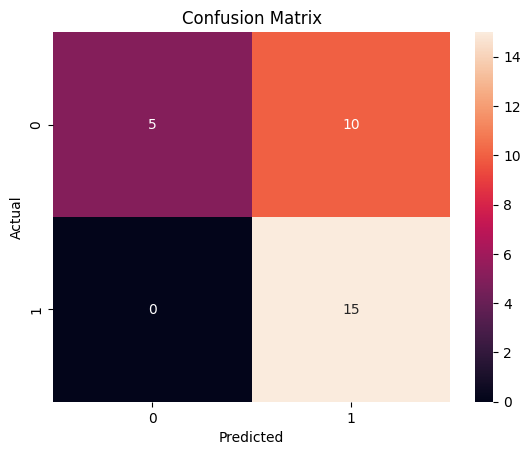

In [46]:
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [47]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

Accuracy: 0.6666666666666666


In [48]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, y_pred_prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.9955555555555555


## model 3

In [49]:
model_3 = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, (3,3),input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(32, (3,3),input_shape=(224,224,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),
   
    tf.keras.layers.Conv2D(64, (3,3),input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(64, (3,3),input_shape=(224,224,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3),input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(128, (3,3),input_shape=(224,224,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256, (3,3),input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(256, (3,3),input_shape=(224,224,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 220, 220, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 220, 220, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 106, 106, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 106, 106, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 49, 49, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 49, 49, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 20, 20, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,207,201 (4.61 MB)

 Trainable params: 1,206,241 (4.60 MB)

 Non-trainable params: 960 (3.75 KB)

In [52]:
model_3.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics= ['accuracy']
                )

In [54]:
history_model_2 = model_3.fit(train_gen,
                              validation_data=val_gen,
                              epochs= 5,
                              class_weight=class_weights,
                              verbose=1
                              )

Epoch 1/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 896s 4s/step - accuracy: 0.8699 - loss: 0.3148 - val_accuracy: 0.5006 - val_loss: 2.1265
Epoch 2/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.9041 - loss: 0.2456 - val_accuracy: 0.5476 - val_loss: 1.4976
Epoch 3/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.9190 - loss: 0.2164 - val_accuracy: 0.9406 - val_loss: 0.1981
Epoch 4/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.9260 - loss: 0.2024 - val_accuracy: 0.8000 - val_loss: 0.4717
Epoch 5/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accuracy: 0.9294 - loss: 0.1901 - val_accuracy: 0.8018 - val_loss: 0.3958


In [56]:
# probabilities (0 → 1)
y_pred_prob = model_3.predict(test_gen)

# convert to 0 or 1
y_pred = (y_pred_prob > 0.4).astype(int).flatten()

# true labels
y_true = test_gen.classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step


In [57]:
print(classification_report(y_true, y_pred, target_names=["Normal", "Pneumonia"]))

              precision    recall  f1-score   support

      Normal       1.00      0.47      0.64        15
   Pneumonia       0.65      1.00      0.79        15

    accuracy                           0.73        30
   macro avg       0.83      0.73      0.71        30
weighted avg       0.83      0.73      0.71        30



In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[ 7  8]
 [ 0 15]]


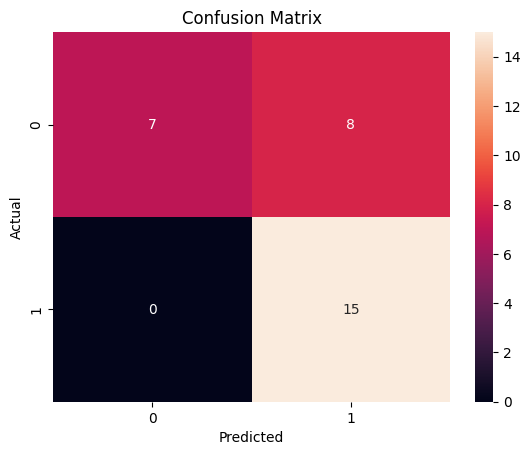

In [59]:
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [60]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

Accuracy: 0.7333333333333333


In [61]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, y_pred_prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.9777777777777779


### In this study, multiple Convolutional Neural Network (CNN) architectures were developed and evaluated for binary classification of chest X-ray images into Normal and Pneumonia classes. Through systematic experimentation with model depth, filter sizes, and regularization techniques such as Dropout and Batch Normalization, the performance of different models was compared.

### Among the three models, Model 1 demonstrated the best overall performance, achieving an accuracy of 93.3% along with a balanced precision and recall. Notably, it achieved 100% recall for pneumonia cases, ensuring that no positive cases were missed, which is critical in medical diagnosis scenarios. While Models 2 and 3 also achieved perfect recall for pneumonia, they suffered from significantly lower recall for normal cases, indicating a bias toward predicting pneumonia and resulting in a high number of false positives.

### These results highlight that increasing model complexity does not necessarily lead to better performance. Instead, a well-balanced architecture with appropriate regularization can outperform deeper or more complex models. Furthermore, the use of evaluation metrics such as precision, recall, F1-score, and confusion matrix proved essential in understanding model behavior beyond simple accuracy, especially in a healthcare context where minimizing false negatives is crucial.

### Overall, the project demonstrates the importance of model design, proper evaluation, and domain-specific metric selection in building reliable machine learning systems. Future improvements can include leveraging transfer learning techniques to further enhance performance and generalization.